# 🦠 Malaria Cell Classification using CNN

## Project Overview

This project uses a Convolutional Neural Network (CNN) to classify blood cell images into two classes:

- **Parasitized**
- **Uninfected**

The project covers image preprocessing, data preparation, CNN model training, and model evaluation.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data_path = "cell_images"

In [ ]:
parasitized_path = os.path.join(data_path, "Parasitized")
uninfected_path = os.path.join(data_path, "Uninfected")

print("Parasitized:", len(os.listdir(parasitized_path)))
print("Uninfected:", len(os.listdir(uninfected_path)))

Parasitized: 13780
Uninfected: 13780


Preprocessing

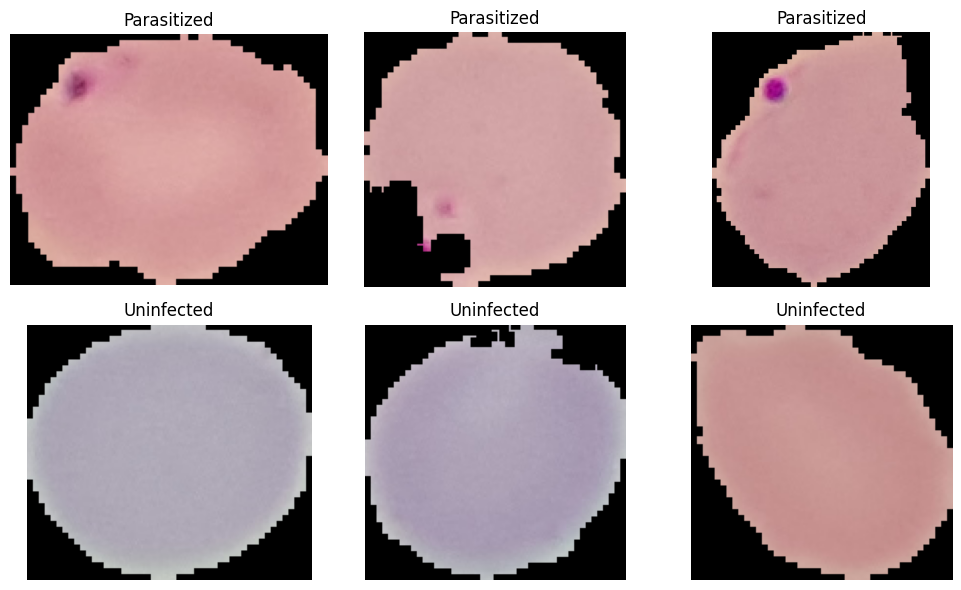

In [ ]:
import random
from PIL import Image

classes = ["Parasitized", "Uninfected"]

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(data_path, class_name)
    images = os.listdir(class_path)

    for j in range(3):
        image_name = random.choice(images)
        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        plt.subplot(2, 3, i * 3 + j + 1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image_name = os.listdir(parasitized_path)[0]
image_path = os.path.join(parasitized_path, image_name)

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

image = image.resize((128, 128))

print("New image size:", image.size)

image_array = np.array(image)

print("Image shape:", image_array.shape)

Image size: (139, 148)
Image mode: RGB
New image size: (128, 128)
Image shape: (128, 128, 3)


In [ ]:
image_array = image_array / 255.0

print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Minimum pixel value: 0.0
Maximum pixel value: 0.8862745098039215


In [ ]:
def preprocess_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = image.resize((128, 128))
    image_array = np.array(image, dtype=np.float32)
    image_array = image_array / 255.0

    return image_array

In [ ]:
images = []
labels = []

In [ ]:
for image_name in os.listdir(parasitized_path):
    if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(parasitized_path, image_name)

        image_array = preprocess_image(image_path)

        images.append(image_array)
        labels.append(1)

In [ ]:
for image_name in os.listdir(uninfected_path):
    if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(uninfected_path, image_name)

        image_array = preprocess_image(image_path)

        images.append(image_array)
        labels.append(0)

In [ ]:
print("Total images:", len(images))
print("Total labels:", len(labels))

print("Parasitized:", labels.count(1))
print("Uninfected:", labels.count(0))

Total images: 27558
Total labels: 27558
Parasitized: 13779
Uninfected: 13779


In [ ]:
import numpy as np
images = np.array(images, dtype=np.float16)
labels = np.array(labels, dtype=np.int8)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (27558, 128, 128, 3)
Labels shape: (27558,)


In [ ]:
del images
del labels

In [ ]:
import gc
gc.collect()

13441

In [ ]:
print(parasitized_path)
print(uninfected_path)

cell_images/Parasitized
cell_images/Uninfected


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

In [ ]:
train_data = datagen.flow_from_directory(
    'cell_images/cell_images',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 22048 images belonging to 2 classes.


In [ ]:
val_data = datagen.flow_from_directory(
   'cell_images/cell_images',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 5510 images belonging to 2 classes.


In [ ]:
import os
import shutil

base_dir = 'cell_images/cell_images'


for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and folder not in ['Parasitized', 'Uninfected']:
        shutil.rmtree(folder_path)
        print(f"{folder} is Removed")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
Flatten()

<Flatten name=flatten_1, built=False>

In [ ]:
Dense(128, activation='relu')

<Dense name=dense_2, built=False>

In [ ]:
Dropout(0.5)

<Dropout name=dropout_4, built=True>

In [ ]:
Dense(1, activation='sigmoid')

<Dense name=dense_3, built=False>

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 157s 212ms/step - accuracy: 0.6628 - loss: 0.7010 - val_accuracy: 0.7731 - val_loss: 0.5537 - learning_rate: 0.0010
Epoch 2/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.8569 - loss: 0.3616 - val_accuracy: 0.7441 - val_loss: 0.4893 - learning_rate: 0.0010
Epoch 3/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 141s 204ms/step - accuracy: 0.9185 - loss: 0.2523 - val_accuracy: 0.9225 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 4/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 139s 202ms/step - accuracy: 0.9328 - loss: 0.2243 - val_accuracy: 0.8682 - val_loss: 0.3345 - learning_rate: 0.0010
Epoch 5/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 154s 223ms/step - accuracy: 0.9389 - loss: 0.2098 - val_accuracy: 0.9372 - val_loss: 0.1832 - learning_rate: 0.0010
Epoch 6/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 141s 205ms/step - accuracy: 0.9382 - loss: 0.2065 - val_accuracy: 0.9027 - val_loss: 0.2539 - learning_rate: 0.0010
Epoch 7/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 155s 225ms/step - accuracy: 0.9

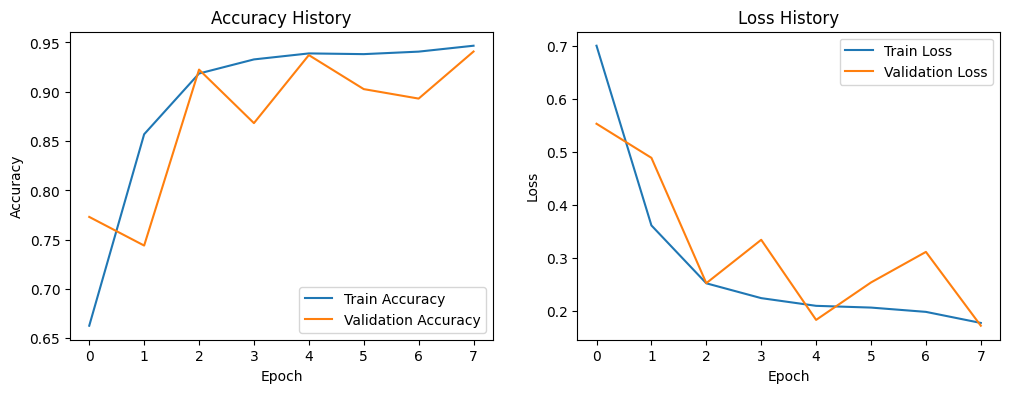

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

135/173 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9227 - loss: 0.1939

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(val_data)
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = val_data.classes

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['Parasitized', 'Uninfected']))

173/173 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step
Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.96      0.92      0.94      2755
  Uninfected       0.92      0.96      0.94      2755

    accuracy                           0.94      5510
   macro avg       0.94      0.94      0.94      5510
weighted avg       0.94      0.94      0.94      5510



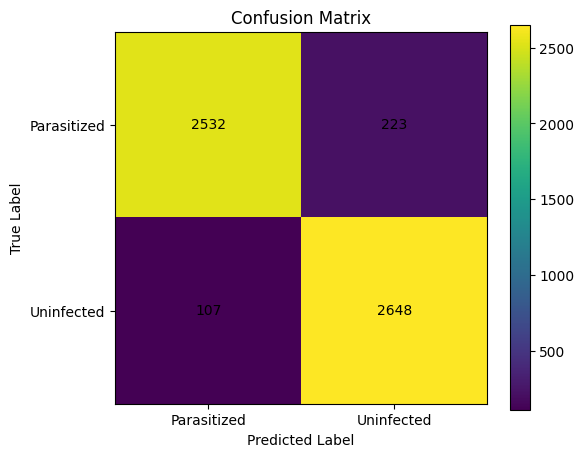

In [ ]:

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks([0, 1], ['Parasitized', 'Uninfected'])
plt.yticks([0, 1], ['Parasitized', 'Uninfected'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image


folder_path = 'cell_images/cell_images/Parasitized'
first_image_name = os.listdir(folder_path)[0]
test_image_path = os.path.join(folder_path, first_image_name)


img = image.load_img(test_image_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)


prediction = model.predict(img_array)[0][0]
result = 'Uninfected' if prediction > 0.5 else 'Parasitized'

print(f"Tested Image: {first_image_name}")
print(f"Prediction: {result} (Probability: {prediction:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
Tested Image: C184P145ThinF_IMG_20151203_104153_cell_146.png
Prediction: Parasitized (Probability: 0.0008)
